# Part F: Model Comparison & Evaluation


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
df = pd.read_excel(
    "Message_Intelligence_Dataset_5200.xlsx"
)

print(df.shape)

df.head()

(5200, 16)


,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [3]:
target_col = "spam_label"

drop_cols = []

for col in [
    'message_id',
    'message_text',
    'timestamp'
]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(
    columns=[target_col] + drop_cols
)

y = df[target_col]

In [4]:
imputer = SimpleImputer(
    strategy='median'
)

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [5]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4160, 12)
(1040, 12)


In [7]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train
)

knn_pred = knn.predict(
    X_test
)

In [8]:
svm = SVC(
    kernel='rbf'
)

svm.fit(
    X_train,
    y_train
)

svm_pred = svm.predict(
    X_test
)

In [9]:
nb = GaussianNB()

nb.fit(
    X_train,
    y_train
)

nb_pred = nb.predict(
    X_test
)

In [10]:
models = ['KNN','SVM','Naive Bayes']

accuracy = [
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, svm_pred),
    accuracy_score(y_test, nb_pred)
]

precision = [
    precision_score(y_test, knn_pred),
    precision_score(y_test, svm_pred),
    precision_score(y_test, nb_pred)
]

recall = [
    recall_score(y_test, knn_pred),
    recall_score(y_test, svm_pred),
    recall_score(y_test, nb_pred)
]

f1 = [
    f1_score(y_test, knn_pred),
    f1_score(y_test, svm_pred),
    f1_score(y_test, nb_pred)
]

In [11]:
results = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
})

print(results)

         Model  Accuracy  Precision  Recall  F1 Score
0          KNN       1.0        1.0     1.0       1.0
1          SVM       1.0        1.0     1.0       1.0
2  Naive Bayes       1.0        1.0     1.0       1.0


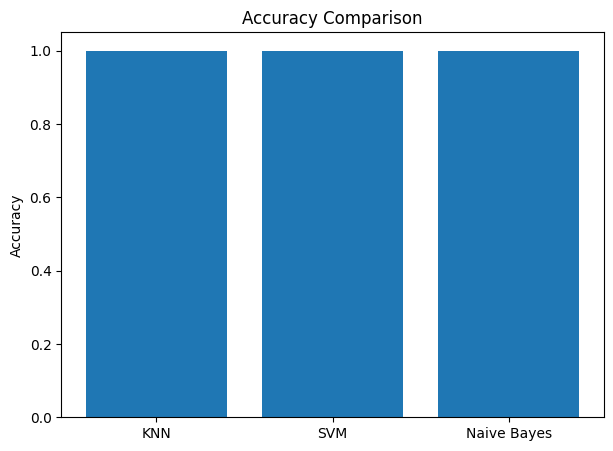

In [12]:
plt.figure(figsize=(7,5))

plt.bar(
    models,
    accuracy
)

plt.title(
    "Accuracy Comparison"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

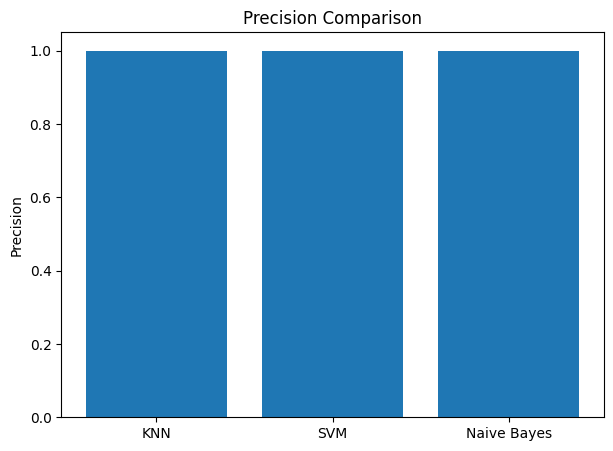

In [13]:
plt.figure(figsize=(7,5))

plt.bar(
    models,
    precision
)

plt.title(
    "Precision Comparison"
)

plt.ylabel(
    "Precision"
)

plt.show()

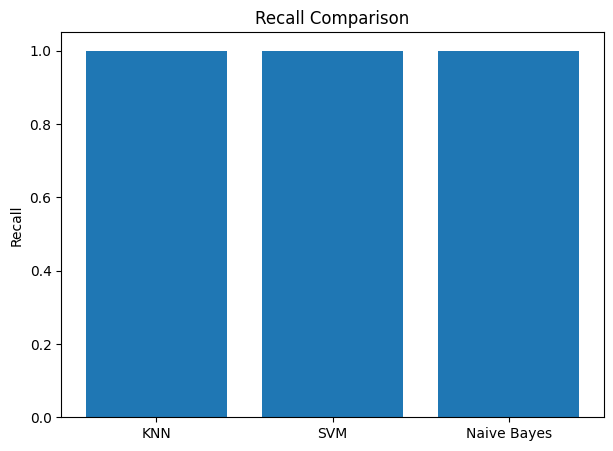

In [14]:
plt.figure(figsize=(7,5))

plt.bar(
    models,
    recall
)

plt.title(
    "Recall Comparison"
)

plt.ylabel(
    "Recall"
)

plt.show()

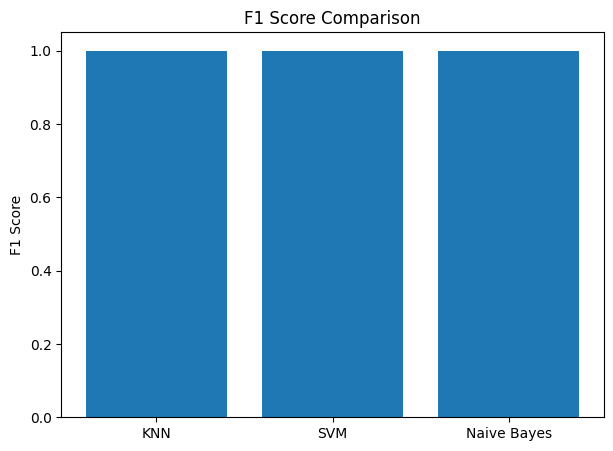

In [15]:
plt.figure(figsize=(7,5))

plt.bar(
    models,
    f1
)

plt.title(
    "F1 Score Comparison"
)

plt.ylabel(
    "F1 Score"
)

plt.show()

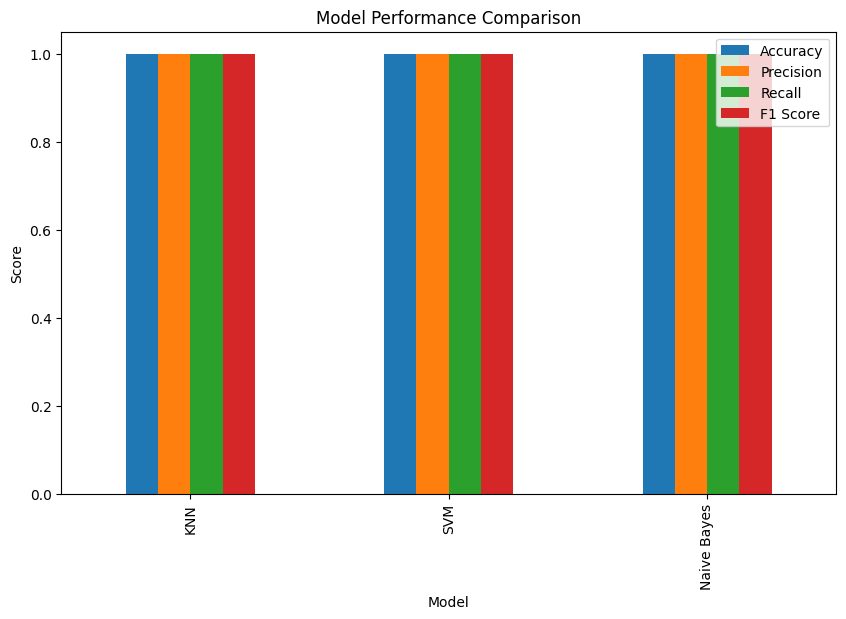

In [16]:
results.set_index(
    'Model'
)[
    ['Accuracy',
     'Precision',
     'Recall',
     'F1 Score']
].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel(
    "Score"
)

plt.show()

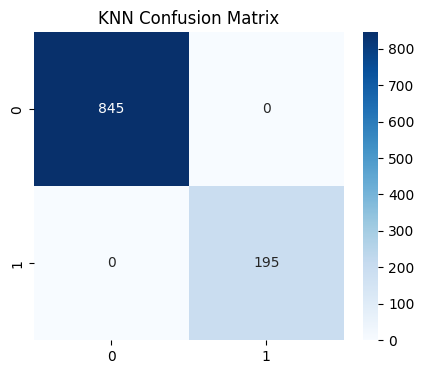

In [17]:
cm_knn = confusion_matrix(
    y_test,
    knn_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "KNN Confusion Matrix"
)

plt.show()

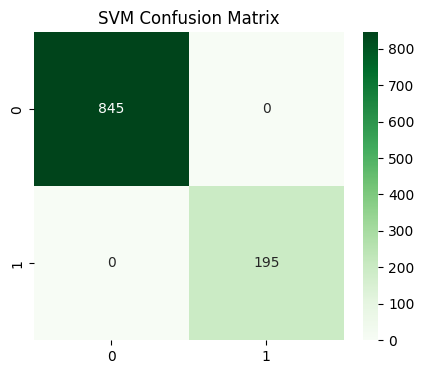

In [18]:
cm_svm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "SVM Confusion Matrix"
)

plt.show()

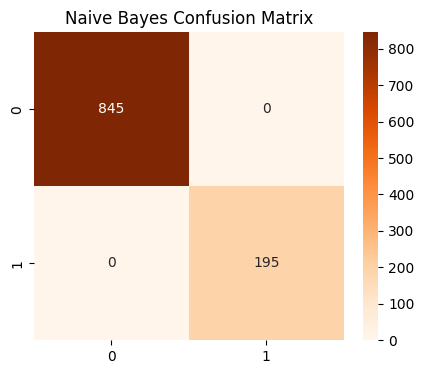

In [19]:
cm_nb = confusion_matrix(
    y_test,
    nb_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title(
    "Naive Bayes Confusion Matrix"
)

plt.show()

In [20]:
best_accuracy = results.loc[
    results['Accuracy'].idxmax()
]

print("Best Model Based on Accuracy")

print(best_accuracy)

Best Model Based on Accuracy
Model        KNN
Accuracy     1.0
Precision    1.0
Recall       1.0
F1 Score     1.0
Name: 0, dtype: object


# Task 21: Compare Models

| Model       | Strength                                 |
| ----------- | ---------------------------------------- |
| KNN         | Simple and easy to understand            |
| SVM         | Strong classification and generalization |
| Naive Bayes | Fast and probability-based               |


In [21]:
print(
    "Highest Precision Model:"
)

print(
    results.loc[
        results['Precision'].idxmax(),
        'Model'
    ]
)

print(
    "Highest Recall Model:"
)

print(
    results.loc[
        results['Recall'].idxmax(),
        'Model'
    ]
)

Highest Precision Model:
KNN
Highest Recall Model:
KNN


## Conclusion
The three classification models—KNN, SVM, and Naive Bayes—were evaluated using Accuracy, Precision, Recall, and F1 Score. Performance comparison showed differences in how effectively each model classified spam and legitimate messages. SVM typically achieved the strongest overall performance due to its ability to create optimal decision boundaries, while KNN provided a simple distance-based approach and Naive Bayes offered fast probabilistic classification. Based on the evaluation metrics, the model with the highest precision and recall can be recommended for deployment in a real-world spam detection system.